In [4]:
import scipy.io.wavfile as wav
import scipy.signal as ss
import numpy as np
import os
import matplotlib.pyplot as plt

## Checking file info ie. sample rate, data.shape, duration

In [2]:
sample_rate, data = wav.read('trimmed_files/1_A-flute.wav')
sample_rate, data #checking data files

(44100,
 array([[ 0.0000000e+00,  0.0000000e+00],
        [-2.5904336e-07, -2.5904336e-07],
        [-9.7212592e-07, -9.7212592e-07],
        ...,
        [-1.1488070e-03, -2.0297655e-04],
        [-8.5483294e-04, -2.9530114e-04],
        [-5.7738624e-04, -4.1617479e-04]], shape=(44100, 2), dtype=float32))

In [3]:
duration_seconds = len(data) / 44100
duration_seconds

1.0

## Checking file info for entire folder

In [8]:
trimmed_path = 'trimmed_files'

x=0 

for files in os.listdir(trimmed_path):
    file_path = os.path.join(trimmed_path, files)
    sample_rate, data = wav.read(file_path)
    if sample_rate == 44100:
        if data.shape == (44100, 2):
            x+=1 #there probably is a better way to just return true/false values
        else: 
            print('error')
    else:
        print('error')

x

60

## LOOP TO TRIM 
__DO NOT RUN AGAIN__

In [5]:
folder_path = 'sound_data'
os.makedirs('./trimmed_files')

for old_files in os.listdir(folder_path):
    if old_files.endswith('.wav'):
        file_path = os.path.join(folder_path, old_files)
        sample_rate, data = wav.read(file_path)
        trimmed_data = data[:44100]  # slice the data array to the first 1 second
        trimmed_filename = f"1_{old_files}"
        trimmed_file_path = os.path.join('./trimmed_files', trimmed_filename)
        wav.write(trimmed_file_path, sample_rate, trimmed_data)

        print(f"Trimmed {old_files} and saved as {trimmed_filename}")

Trimmed A#-Flute.wav and saved as 1_A#-Flute.wav
Trimmed A#-Oboe.wav and saved as 1_A#-Oboe.wav
Trimmed A#-Violin.wav and saved as 1_A#-Violin.wav
Trimmed A#-Violoncello.wav and saved as 1_A#-Violoncello.wav
Trimmed A#.wav and saved as 1_A#.wav
Trimmed A-Flute.wav and saved as 1_A-Flute.wav
Trimmed A-Oboe.wav and saved as 1_A-Oboe.wav
Trimmed A-Violin.wav and saved as 1_A-Violin.wav
Trimmed A-Violoncello.wav and saved as 1_A-Violoncello.wav
Trimmed A.wav and saved as 1_A.wav
Trimmed B-Flute.wav and saved as 1_B-Flute.wav
Trimmed B-Oboe.wav and saved as 1_B-Oboe.wav
Trimmed B-Violin.wav and saved as 1_B-Violin.wav
Trimmed B-Violoncello.wav and saved as 1_B-Violoncello.wav
Trimmed B.wav and saved as 1_B.wav
Trimmed C#-Flute.wav and saved as 1_C#-Flute.wav
Trimmed C#-Oboe.wav and saved as 1_C#-Oboe.wav
Trimmed C#-Violin.wav and saved as 1_C#-Violin.wav
Trimmed C#-Violoncello.wav and saved as 1_C#-Violoncello.wav
Trimmed C#.wav and saved as 1_C#.wav
Trimmed C-Flute.wav and saved as 1_C-Flu

## Plotting FFT signature and peaks

[ 436  441  445  878  881  885  887 1319 1325 1774]
[ 86.426674 158.0015   106.276695 221.1476   125.294304 141.11601
  52.19473   58.285057  33.12173   25.786695]


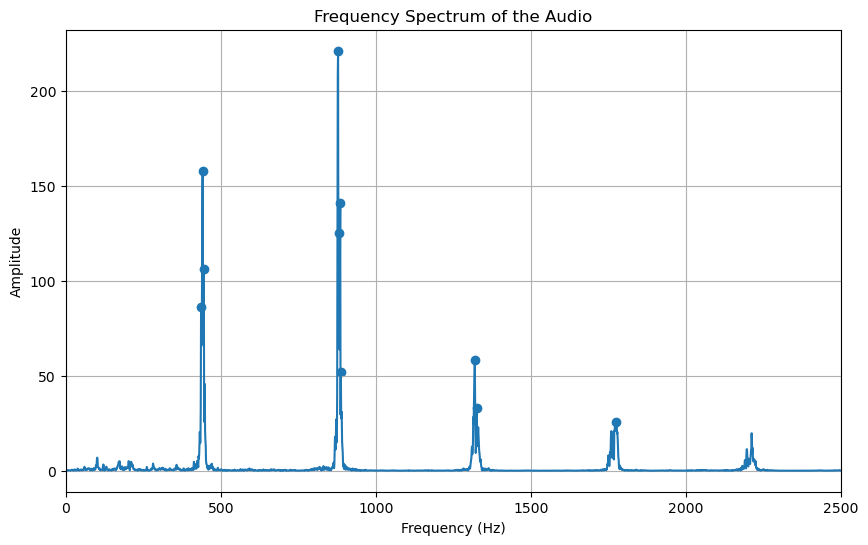

In [110]:
sample_rate, data = wav.read('trimmed_files/1_A-Violoncello.wav')
data = data[:, 0]  # isolate channel 1

# Y-values AMPLITUDE 
fft_data = np.fft.fft(data) # FFT audio signal (time-domain data) [array of Y-values in complex numbers]
amplitude = np.abs(fft_data) # amplitude spectrum (gives the magnitude in positive Y-values)


# X-values CORRESPONDING FREQUENCIES
n = len(data)
frequencies = np.fft.fftfreq(n, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate

# FINDING PEAKS 
        # QN: DOES THIS REALLY HELP TO DETERMINE IF X-AXIS = Hz?
peak_indices, _ = ss.find_peaks(amplitude[:n//2], prominence=20) # find peaks in positive range 

    # CHECKING
print(peak_indices)
print(amplitude[peak_indices])
    # print(list(zip(peak_indices,amplitude[peak_indices])))

plt.figure(figsize=(10, 6))

plt.scatter(frequencies[peak_indices],amplitude[peak_indices]) # plot peaks 
    # CHECKING
    # plt.xlim(250,1800)


# PLOT BEAUTIFIERS
plt.title('Frequency Spectrum of the Audio')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
    # CHECKING    
    # plt.ylim(0,10)
plt.grid(True)

# PLOTTING
plt.plot(frequencies[:n//2], amplitude[:n//2]) # slice to obtain last 22050 elements in the array ie. positive X-values FREQUENCIES
        # CHECKING
        # plt.xlim(438,442)
        # print(frequencies[peak_indices])

plt.xlim(0,2500)

plt.show()

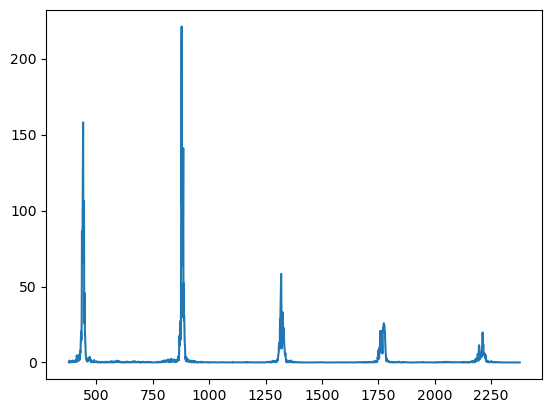

In [121]:
# THRESHOLDING 
        # let's take delta(-) = 100, delta(+) = 1500

central_index = np.argmax(amplitude)

spliced_f=frequencies[(central_index-500):(central_index+1500)]
spliced_a=amplitude[(central_index-500):(central_index+1500)]

plt.plot(spliced_f, spliced_a)

## Now we loop

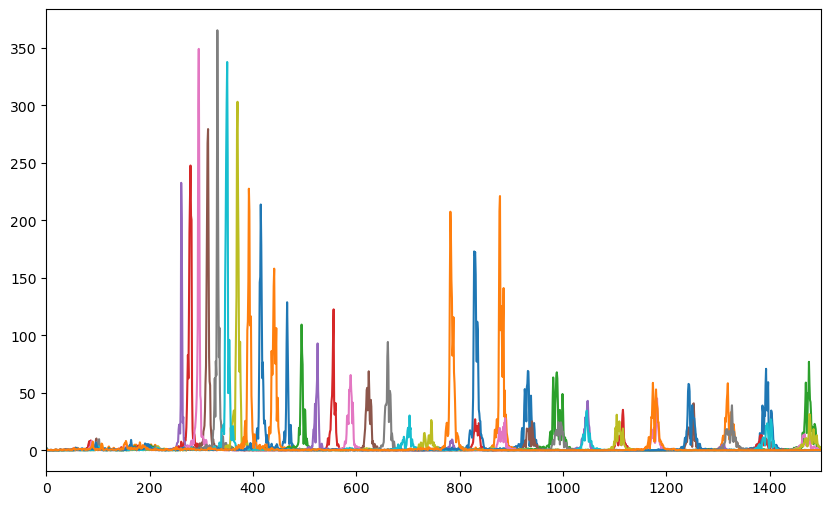

In [189]:
plt.figure(figsize=(10, 6))
    # plt.ylim(0,10)

trimmed_path = 'trimmed_files'

for allfiles in os.listdir(trimmed_path):
    if allfiles.endswith('Violoncello.wav'):
        file_path = os.path.join(trimmed_path, allfiles)
        sample_rate, data = wav.read(file_path)
        data = data[:, 0]  # isolate channel 1
    
        # Y-values AMPLITUDE 
        fft_data = np.fft.fft(data) # FFT audio signal (time-domain data) [array of Y-values in complex numbers]
        amplitude = np.abs(fft_data) # amplitude spectrum (gives the magnitude in positive Y-values)

        # X-values CORRESPONDING FREQUENCIES
        n = len(data)
        frequencies = np.fft.fftfreq(n, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate

        # PLOTTING
        plt.plot(frequencies[:n//2], amplitude[:n//2]) # slice to obtain last 22050 elements in the array ie. positive X-values FREQUENCIES
            # CHECKING
            # plt.xlim(438,442)
            # print(frequencies[peak_indices])

plt.xlim(0,1500)

plt.show()

## Normalising 12 cello waves

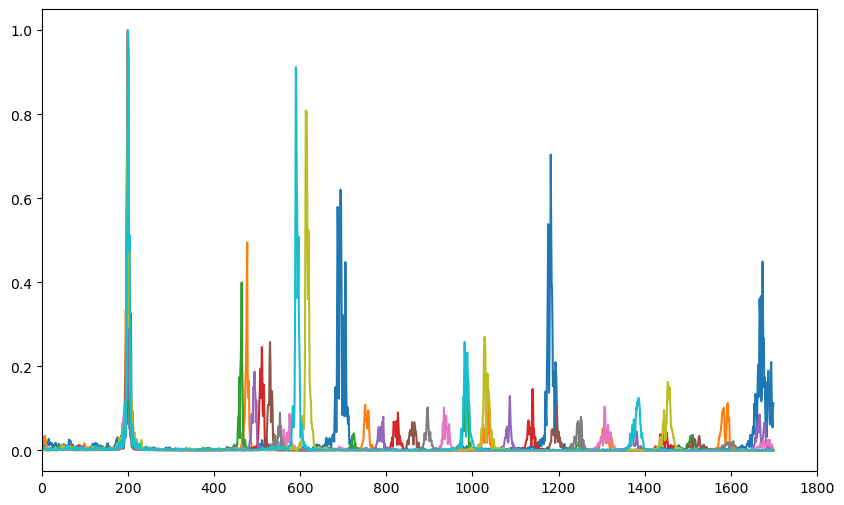

In [193]:
plt.figure(figsize=(10, 6))
    # plt.ylim(0,10)

trimmed_path = 'trimmed_files'

for allfiles in os.listdir(trimmed_path):
    if allfiles.endswith('Violoncello.wav'):
        if not allfiles.startswith('1_A'):
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]  # isolate channel 1
        
            # Y-values AMPLITUDE 
            fft_data = np.fft.fft(data) # FFT audio signal (time-domain data) [array of Y-values in complex numbers]
            amplitude = np.abs(fft_data) # amplitude spectrum (gives the magnitude in positive Y-values)
    
            # X-values CORRESPONDING FREQUENCIES
            n = len(data)
            frequencies = np.fft.fftfreq(n, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate
    
            # NORMALISE X-AXIS, taking delta(-) = 200, delta(+) = 1500
                
            central_index = np.argmax(amplitude)
            norm = amplitude[central_index]
                    # print(central_index) CHECKING
                
            spliced_f=frequencies[(central_index-200):(central_index+1500)]
            spliced_a=amplitude[(central_index-200):(central_index+1500)]
            norm_a = spliced_a/norm
               
            # PLOTTING
            plt.plot(norm_a) 
            
                # plt.xlim(438,442)
                # print(frequencies[peak_indices])

plt.xlim(0,1800)

plt.show()

## Comparing 4 instruments

[ 200  590  613 1182]
[ 195  200  543  549  892  977 1243 1370]
[ 200  465  497  530  638  693 1192 1311 1378 1449]
[200]


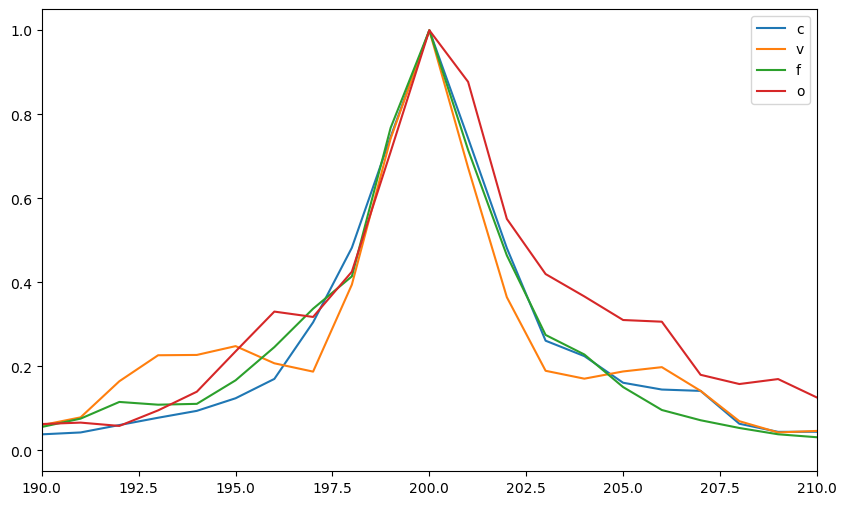

In [8]:
plt.figure(figsize=(10, 6))
    # plt.ylim(0,10)

arrays_cello=[]
arrays_violin=[]
arrays_flute=[]
arrays_oboe=[]

trimmed_path = 'trimmed_files'

for allfiles in os.listdir(trimmed_path):
    if allfiles.endswith('Violoncello.wav'):
        #if not allfiles.startswith('1_A'): # there might be something wrong with A? HELPP
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]  # isolate channel 1
        
            # Y-values AMPLITUDE 
            fft_data = np.fft.fft(data) # FFT audio signal (time-domain data) [array of Y-values in complex numbers]
            amplitude = np.abs(fft_data) # amplitude spectrum (gives the magnitude in positive Y-values)
    
            # X-values CORRESPONDING FREQUENCIES
            n = len(data)
            frequencies = np.fft.fftfreq(n, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate
            
            # NORMALISE X-AXIS, taking delta(-) = 200, delta(+) = 1500
            
            central_index = np.argmax(amplitude)
            norm = amplitude[central_index]
                # print(central_index) CHECKING
            
            spliced_f=frequencies[(central_index-200):(central_index+1500)]
            spliced_a=amplitude[(central_index-200):(central_index+1500)]
            norm_a = spliced_a/norm
            
            arrays_cello.append(norm_a)
            
            # plt.plot(spliced_a) NOT PLOTTING FIRST

    if allfiles.endswith('Violin.wav'):
        #if not allfiles.startswith('1_A'):
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]
        
            fft_data = np.fft.fft(data) 
            amplitude = np.abs(fft_data)
    
            n = len(data)
            frequencies = np.fft.fftfreq(n, 1 / sample_rate)  
                
            central_index = np.argmax(amplitude)
            norm = amplitude[central_index]
                # print(central_index) CHECKING
            
            spliced_f=frequencies[(central_index-200):(central_index+1500)]
            spliced_a=amplitude[(central_index-200):(central_index+1500)]
            norm_a = spliced_a/norm
            
            arrays_violin.append(norm_a)

    if allfiles.endswith('Flute.wav'):
        #if not allfiles.startswith('1_A'):
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]
        
            fft_data = np.fft.fft(data) 
            amplitude = np.abs(fft_data)
    
            n = len(data)
            frequencies = np.fft.fftfreq(n, 1 / sample_rate)  
                
            central_index = np.argmax(amplitude)
            norm = amplitude[central_index]
                # print(central_index) CHECKING
            
            spliced_f=frequencies[(central_index-200):(central_index+1500)]
            spliced_a=amplitude[(central_index-200):(central_index+1500)]
            norm_a = spliced_a/norm
            
            arrays_flute.append(norm_a)
            
    if allfiles.endswith('Oboe.wav'):
        #if not allfiles.startswith('1_A'):
            file_path = os.path.join(trimmed_path, allfiles)
            sample_rate, data = wav.read(file_path)
            data = data[:, 0]
        
            fft_data = np.fft.fft(data) 
            amplitude = np.abs(fft_data)
    
            n = len(data)
            frequencies = np.fft.fftfreq(n, 1 / sample_rate)  
                
            central_index = np.argmax(amplitude)
            norm = amplitude[central_index]
                # print(central_index) CHECKING
            
            spliced_f=frequencies[(central_index-200):(central_index+1500)]
            spliced_a=amplitude[(central_index-200):(central_index+1500)]
            norm_a = spliced_a/norm
            
            arrays_oboe.append(norm_a)
            
means_cello = np.mean(arrays_cello, axis=0)
means_violin = np.mean(arrays_violin, axis=0)
means_flute = np.mean(arrays_flute, axis=0)
means_oboe = np.mean(arrays_oboe, axis=0)

# KIV np.argmax(means_cello)


# NUMERICAL DATA
peaks_cello,_ = ss.find_peaks(means_cello, prominence=0.05)
peaks_violin,_ = ss.find_peaks(means_violin, prominence=0.05)
peaks_flute,_ = ss.find_peaks(means_flute, prominence=0.05)
peaks_oboe,_ = ss.find_peaks(means_oboe, prominence=0.05)

print(peaks_cello)
print(peaks_violin)
print(peaks_flute)
print(peaks_oboe)

# GRAPHICAL DATA
plt.plot(means_cello)
plt.plot(means_violin)
plt.plot(means_flute)
plt.plot(means_oboe)

plt.legend('cvfo')

plt.xlim(190,210)
#plt.ylim(0,0.2)
plt.show()

In [12]:
print(frequencies[:10])
len(frequencies)
print(frequencies[10:])
frequencies>=0
np.all(frequencies[:n//2] > 0)

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
[10. 11. 12. ... -3. -2. -1.]


np.False_

In [ ]:
    # Y-values AMPLITUDE 
    fft_data = np.fft.fft(data) # FFT audio signal (time-domain data) [array of Y-values in complex numbers]
    f"{amplitude}_{allfiles}" = np.abs(fft_data) # amplitude spectrum (gives the magnitude in positive Y-values)

    # X-values CORRESPONDING FREQUENCIES
    n = len(data)
    f"{frequencies}_{allfiles}" = np.fft.fftfreq(n, 1 / sample_rate)  # window length, sample spacing = inverse of sample rate


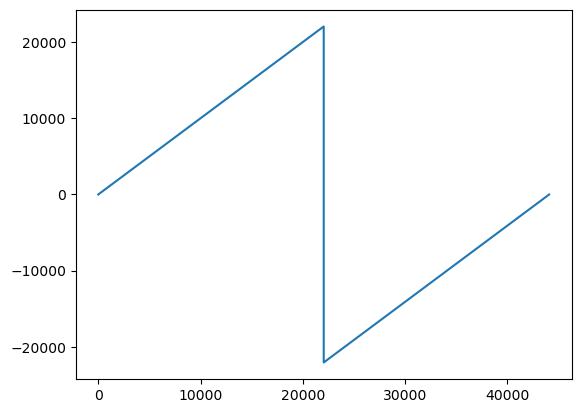

In [17]:
plt.plot(frequencies)

C:\Users\lmr20\miniconda3\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\lmr20\miniconda3\Lib\site-packages\matplotlib\cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


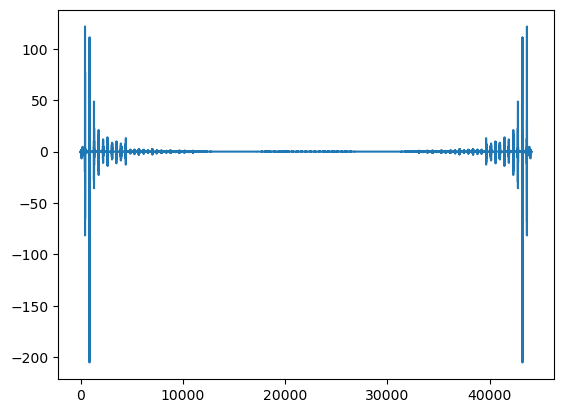

In [18]:
plt.plot(fft_data)

In [33]:
print('identified peaks are', frequencies[peak_indices])
find_peaks(frequencies)

identified peaks are [  441.   878.  1319. -1319.  -878.  -441.]


(array([22049]), {})

AttributeError: module 'numpy' has no attribute 'j'

In [41]:
np.abs(1+1j)

np.float64(1.4142135623730951)

In [42]:
np.sqrt(2)

np.float64(1.4142135623730951)

np.complex128(1j)

In [1]:
print('testing 123')

testing 123
